In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
letters = list(sorted(set("".join(word for word in words))))

itos = {i+1:s for i,s in enumerate(letters)}
itos[0] = '.'

stoi = {s:i for i,s in itos.items()}
n_letters = len(stoi)

In [4]:
block_size = 3
def build_dataset(words):
    X = []
    Y = []
    for word in words:
        word_padded = "." * block_size + word + '.'
        for i in range(len(word_padded) - block_size):
            x = word_padded[i:block_size+i]
            x_encoded = [stoi[letter] for letter in x]
            y = word_padded[block_size+i]
            y_encoded = stoi[y]
            X.append(x_encoded)
            Y.append(y_encoded)

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random 
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [5]:
embedding_dim = 10
nodes1 = 100

In [ ]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn(n_letters, embedding_dim, generator=g) # each letter in alphabet + '.' has a 2 letter embedding
W1 = torch.randn(block_size*embedding_dim, nodes1, generator=g)
b1 = torch.randn(nodes1, generator=g)
W2 = torch.randn(nodes1, n_letters, generator=g)
b2 = torch.randn(n_letters, generator=g)
parameters = [C, W1, b1, W2, b2]
n_params = sum(param.nelement() for param in parameters)
n_params

6097

In [7]:
def train_model(X, Y, num_steps, parameters, lr):
    for p in parameters:
        p.requires_grad = True
    C = parameters[0]
    W1 = parameters[1]
    b1 = parameters[2]
    W2 = parameters[3]
    b2 = parameters[4]
    stepi = []
    lossi = []
    loglossi = []

    for i in range(num_steps):

        ix = torch.randint(0, X.shape[0], (32,))

        # forward pass
        emb = C[X[ix]]
        emb = emb.view(emb.shape[0], block_size*embedding_dim)
        h = torch.tanh(emb @ W1 + b1)
        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, Y[ix])

        # backwards pass
        for p in parameters:
            p.grad = None
        loss.backward()

        # update
        for p in parameters:
            p.data += -lr * p.grad


        # track stats
        stepi.append(i)
        lossi.append(loss.item())
        loglossi.append(loss.log10().item())
        stats = [stepi, lossi, loglossi]
    return parameters, loss, stats

In [8]:
parameters, loss, stats = train_model(Xtr, Ytr, 50000, parameters, lr=0.1)
stepi, lossi, loglossi = stats[0], stats[1], stats[2]

In [9]:
def evaluate(Xdev, Ydev):
    emb = C[Xdev]
    emb = emb.view(emb.shape[0], block_size*embedding_dim)
    h = torch.tanh(emb @ W1 + b1) 
    logits = h @ W2 + b2
    loss_dev = F.cross_entropy(logits, Ydev)
    return loss_dev.item()

In [10]:
evaluate(Xdev, Ydev)

2.2784526348114014

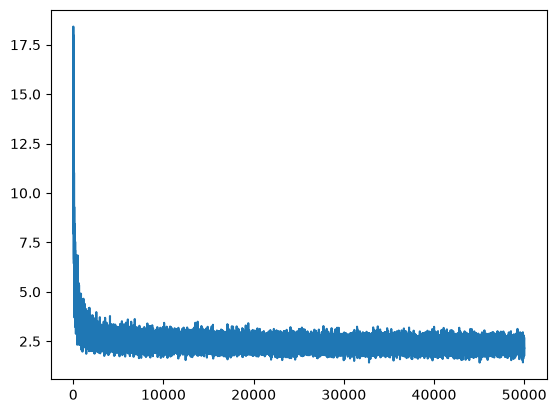

In [11]:
plt.plot(stepi,lossi)

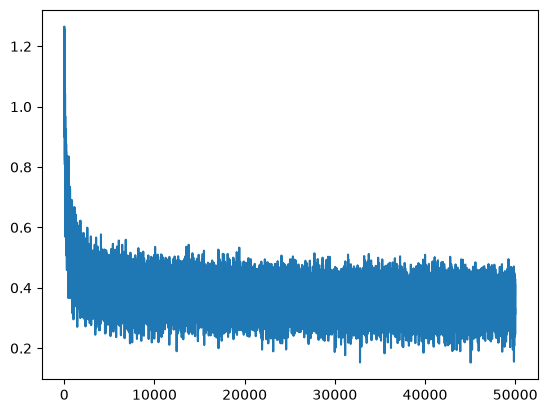

In [12]:
plt.plot(stepi, loglossi)

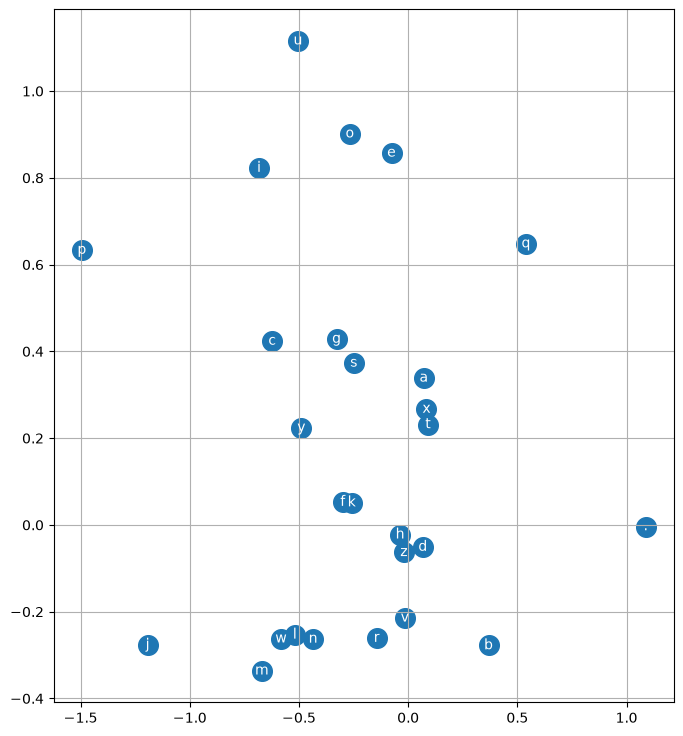

In [13]:
plt.figure(figsize=(8,9))
C = parameters[0]
plt.scatter(C[:,0].data,C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item() ,C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')

In [14]:
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

cate.
celyn.
jani.
loinera.
blana.
jayla.
reckess.
lenn.
mehli.
jenglis.
asra.
izlamarolle.
gonce.
ene.
kazki.
lanna.
jayilakel.
oland.
nli.
densi.
